<a href="https://colab.research.google.com/github/oscarmunoz1-glitch/IntroduccionIA_20252/blob/main/02_preprocesado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

primero cargamos el archivo kaggle.json que es el api token de kaggle


In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"oscarmunoz10","key":"b50dac9fd79fccd5718c9f473a8179f7"}'}

Configuramos los permisos y descargamos los archivos

In [5]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

!chmod 600 /content/kaggle.json

descargamos los archivos directamente desde kaggle

In [6]:
!kaggle competitions download -c udea-ai-4-eng-20252-pruebas-saber-pro-colombia

  0% 0.00/29.9M [00:00<?, ?B/s]
100% 29.9M/29.9M [00:00<00:00, 1.28GB/s]


descomprimimos el archivo zip

In [7]:
import zipfile

# Descomprime el archivo
with zipfile.ZipFile("udea-ai-4-eng-20252-pruebas-saber-pro-colombia.zip", 'r') as zip_ref:
    zip_ref.extractall("udea-ai-4-eng-20252-pruebas-saber-pro-colombia")


listamos los archivos descomprimidos

In [8]:
print(os.listdir('udea-ai-4-eng-20252-pruebas-saber-pro-colombia'))

['train.csv', 'submission_example.csv', 'test.csv']


con panda cargamos el archivo train.csv y con df.head visualizamos las primeras filas para poder ver las categorias

In [9]:
import pandas as pd

df = pd.read_csv('udea-ai-4-eng-20252-pruebas-saber-pro-colombia/train.csv')

# Muestra las primeras filas del DataFrame
from IPython.display import display

display(df.head())


,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,...,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,...,N,No,Si,Si,Postgrado,medio-alto,0.322,0.208,0.310,0.267
1,645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,...,N,No,Si,No,Técnica o tecnológica incompleta,bajo,0.311,0.215,0.292,0.264
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,...,N,No,No,Si,Secundaria (Bachillerato) completa,bajo,0.297,0.214,0.305,0.264
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,...,N,No,Si,Si,Secundaria (Bachillerato) completa,alto,0.485,0.172,0.252,0.190
4,989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,...,N,No,Si,Si,Primaria completa,medio-bajo,0.316,0.232,0.285,0.294


Verificamos la cantidad de valores nulos en cada columna

In [10]:
df.isnull().sum()

,0
ID,0
PERIODO_ACADEMICO,0
E_PRGM_ACADEMICO,0
E_PRGM_DEPARTAMENTO,0
E_VALORMATRICULAUNIVERSIDAD,6287
E_HORASSEMANATRABAJA,30857
F_ESTRATOVIVIENDA,32137
F_TIENEINTERNET,26629
F_EDUCACIONPADRE,23178
F_TIENELAVADORA,39773


Calcular el porcentaje de datos faltante por columna

In [11]:
# Calcular el porcentaje de valores faltantes por columna
valores_faltantes= df.isna().sum() / len(df) * 100

# Filtrar columnas con valores faltantes y ordenarlas
valores_faltantes[valores_faltantes > 0].sort_values(ascending=False)

,0
F_TIENEAUTOMOVIL,6.299350
F_TIENELAVADORA,5.743394
F_TIENECOMPUTADOR,5.502238
F_ESTRATOVIVIENDA,4.640722
E_HORASSEMANATRABAJA,4.455884
F_TIENEINTERNET.1,3.845343
F_TIENEINTERNET,3.845343
F_EDUCACIONMADRE,3.417184
F_EDUCACIONPADRE,3.347004
E_PAGOMATRICULAPROPIO,0.938339


Contamos los valores nulos por columnas y se crean graficos de barras

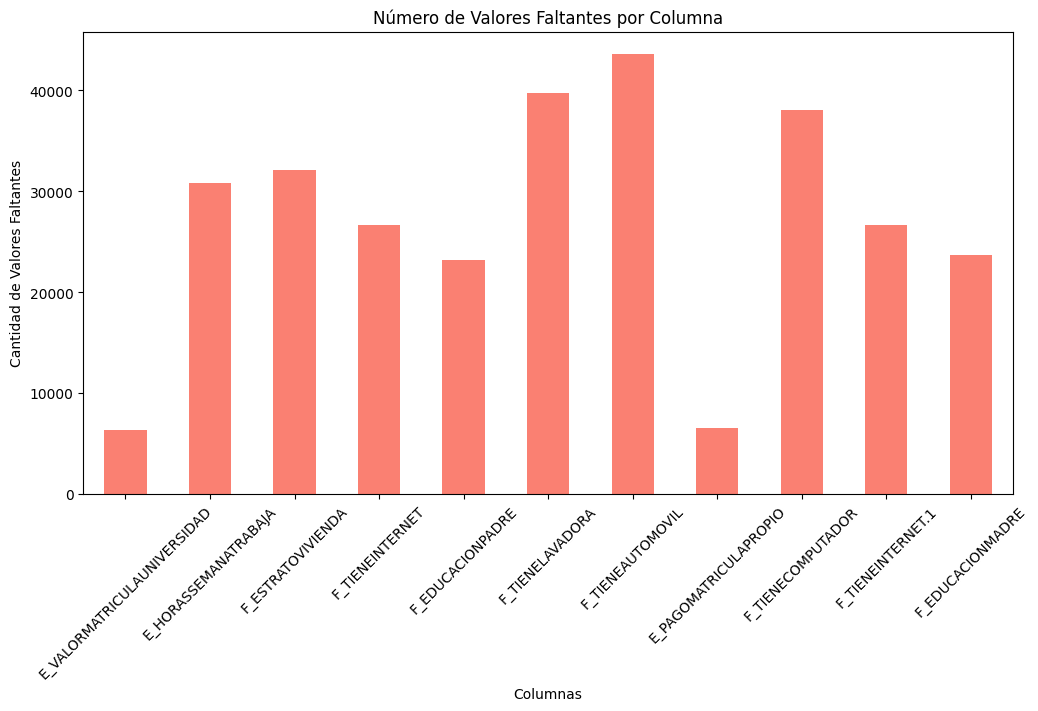

In [12]:
import matplotlib.pyplot as plt
# Contamos valores faltantes por columna
missing_counts = df.isnull().sum()

# Creamos un gráfico de barras
plt.figure(figsize=(12, 6))
missing_counts[missing_counts > 0].plot(kind='bar', color='salmon')
plt.title('Número de Valores Faltantes por Columna')
plt.xlabel('Columnas')
plt.ylabel('Cantidad de Valores Faltantes')
plt.xticks(rotation=45)
plt.show()

Se instalan las librerias matplotlib y seaborn

In [13]:
!pip install matplotlib seaborn

Se crean graficos de barras con variables categoricas vs el rendimiento global

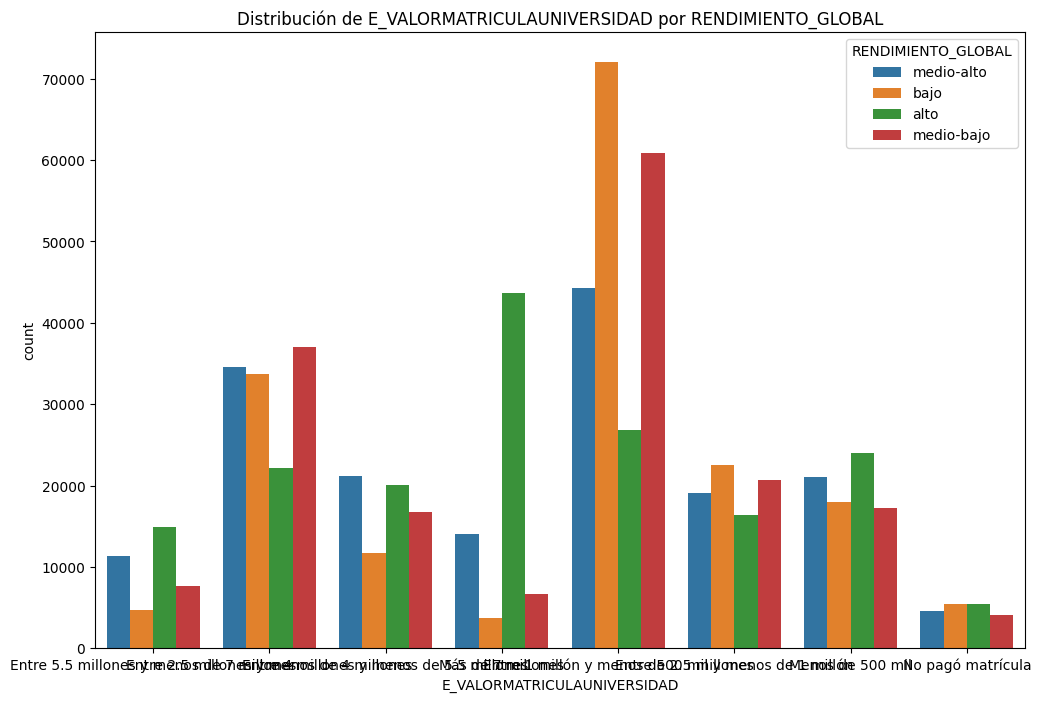

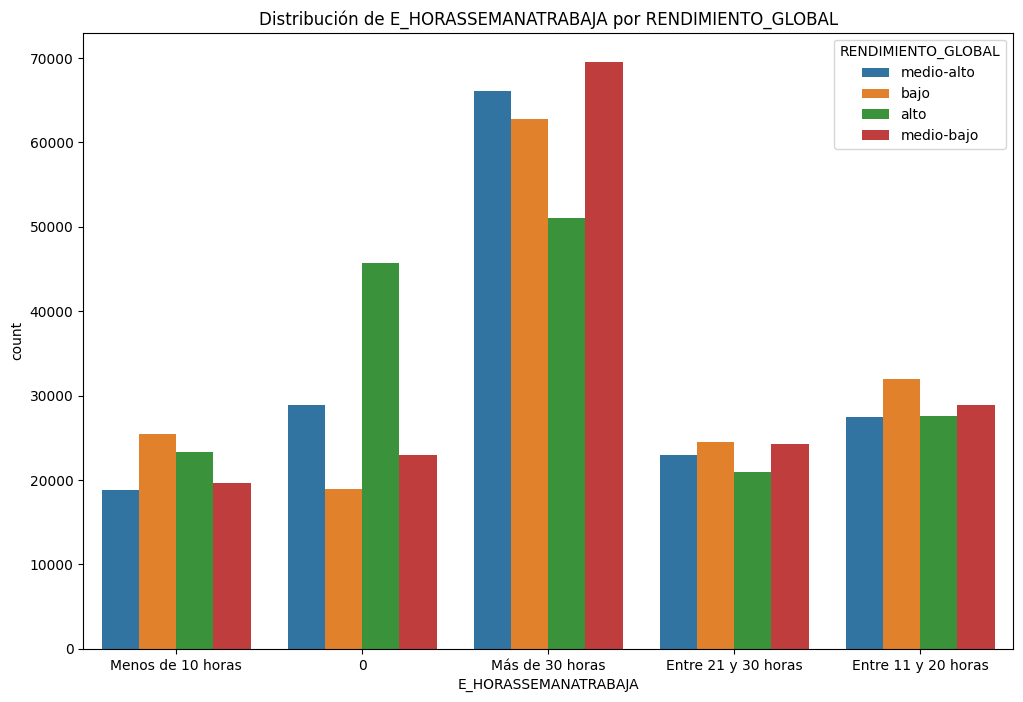

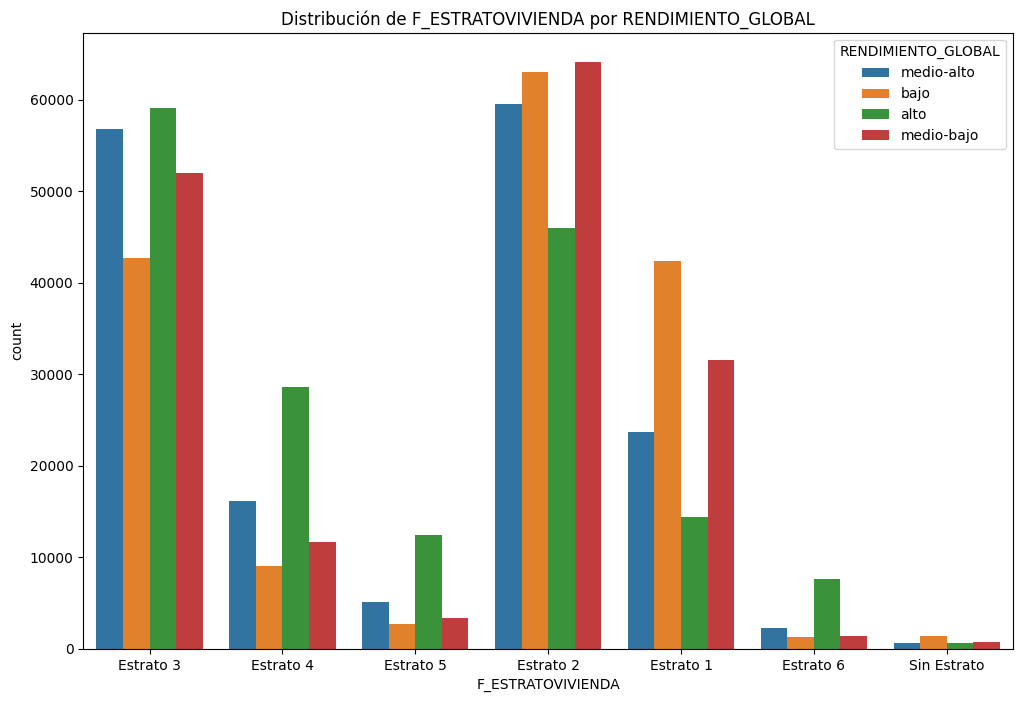

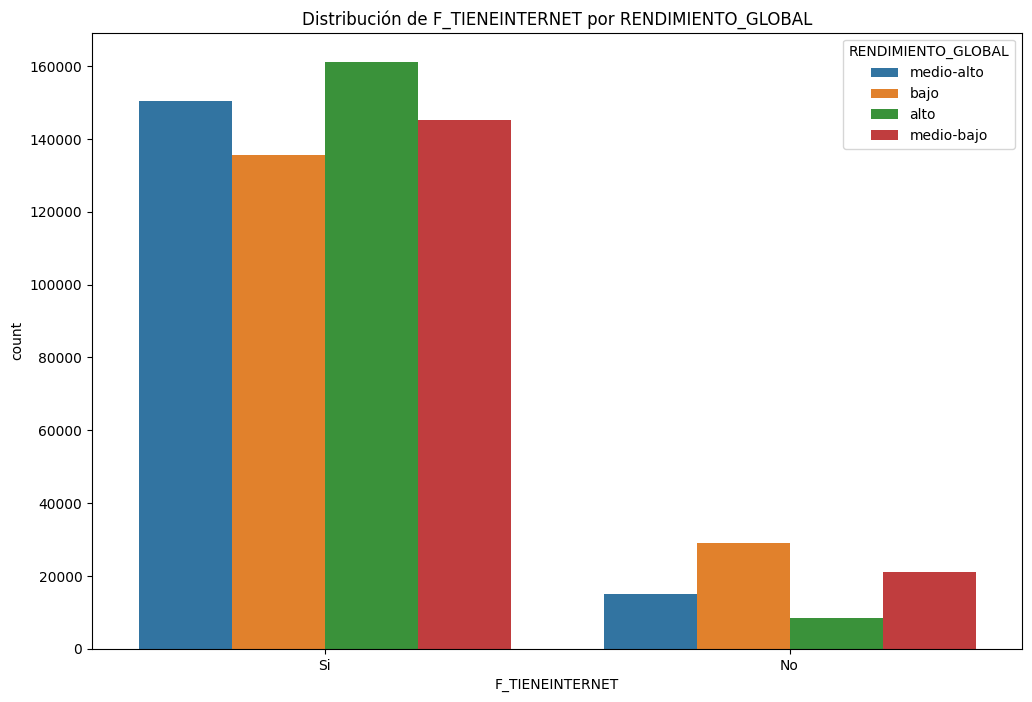

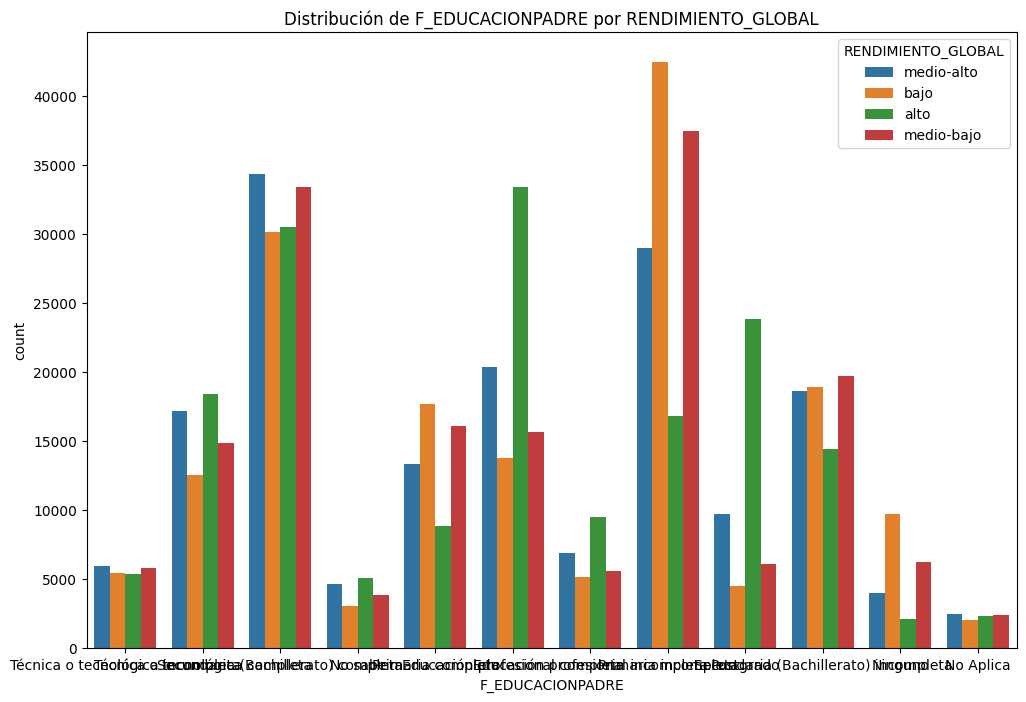

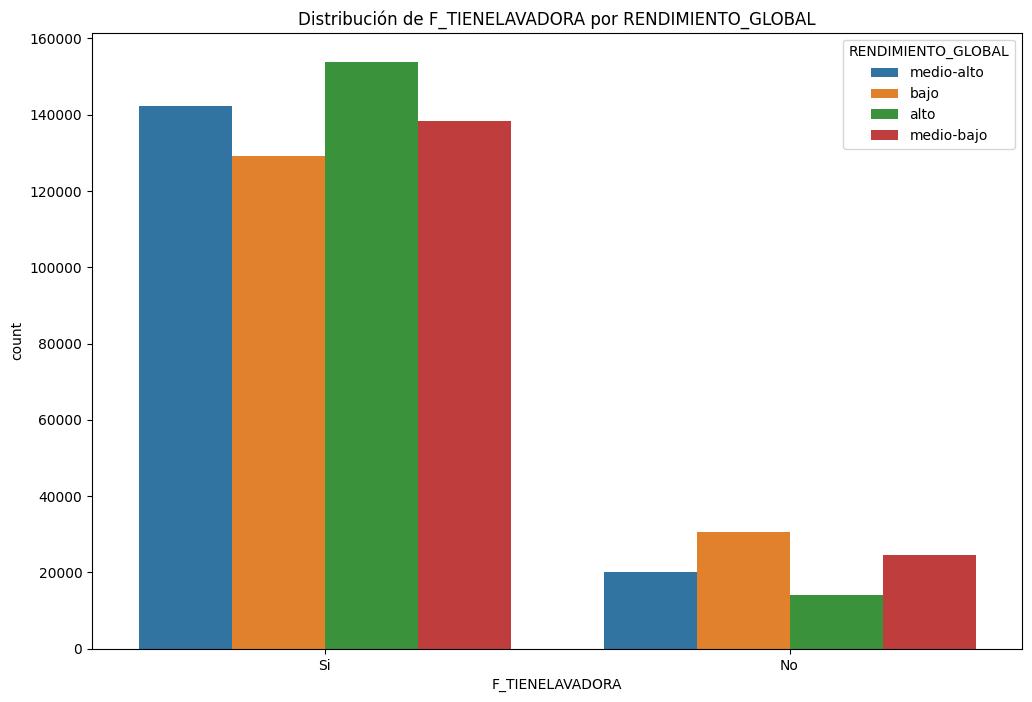

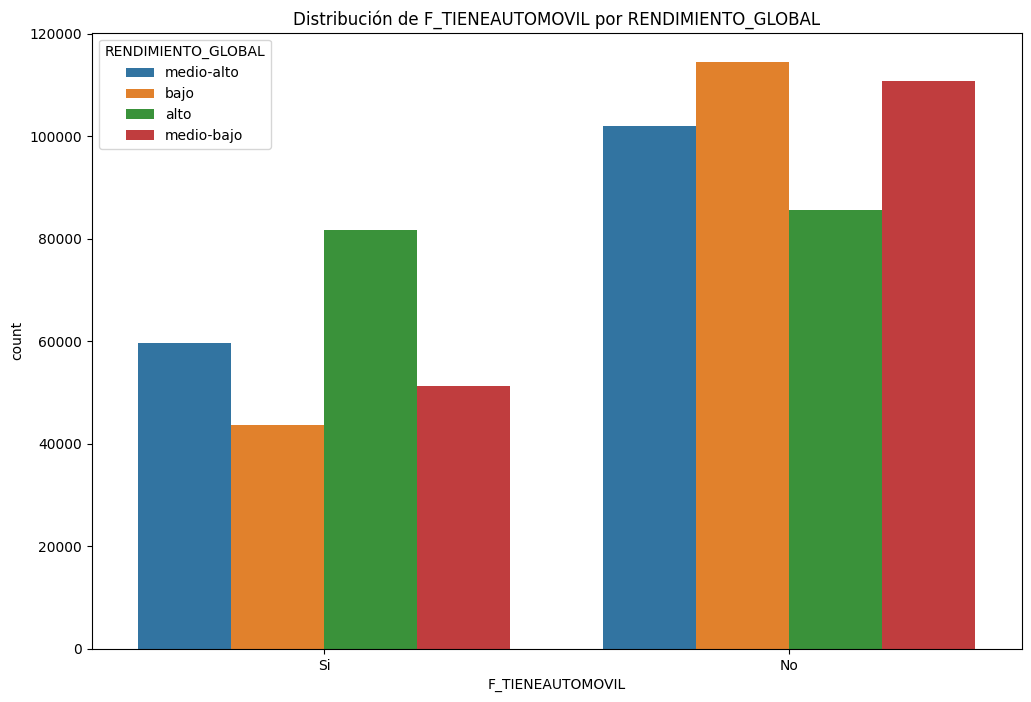

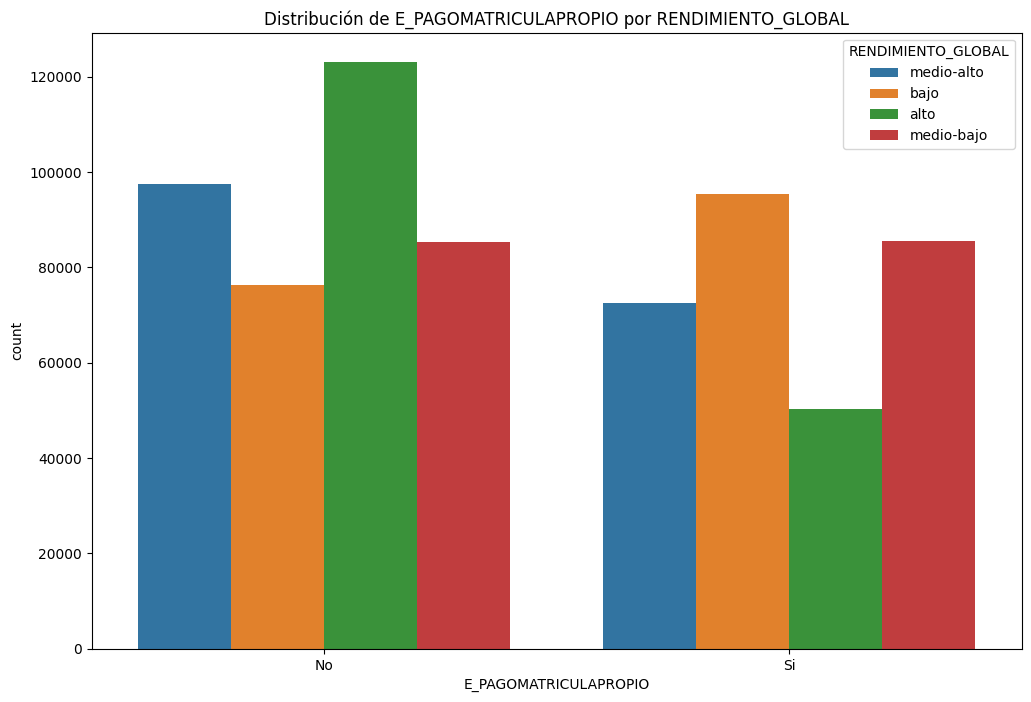

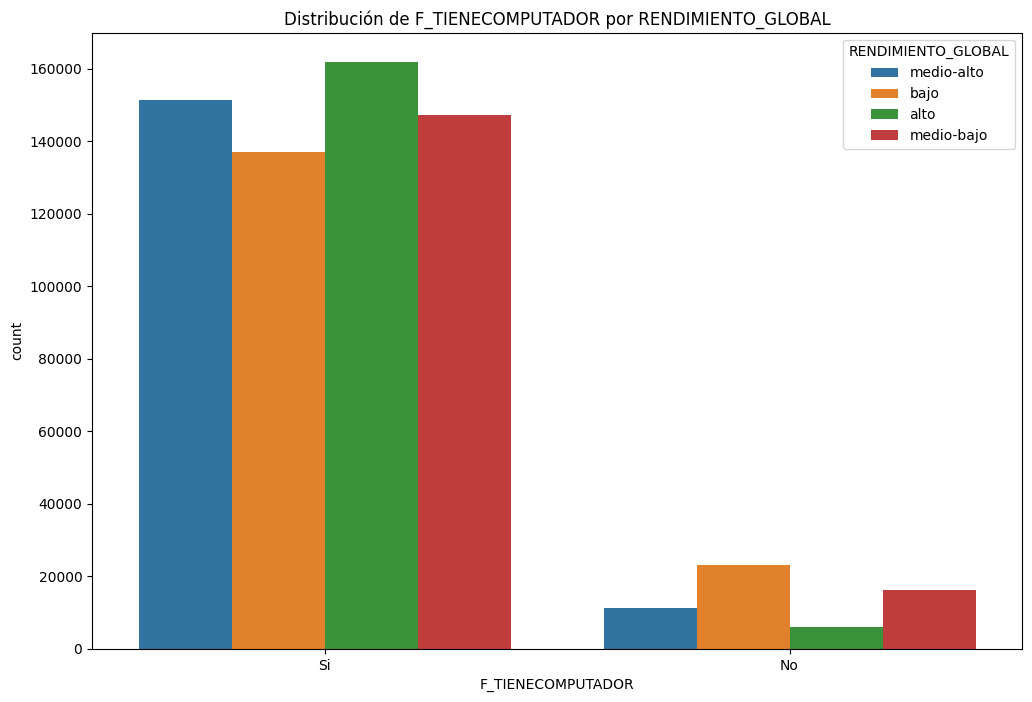

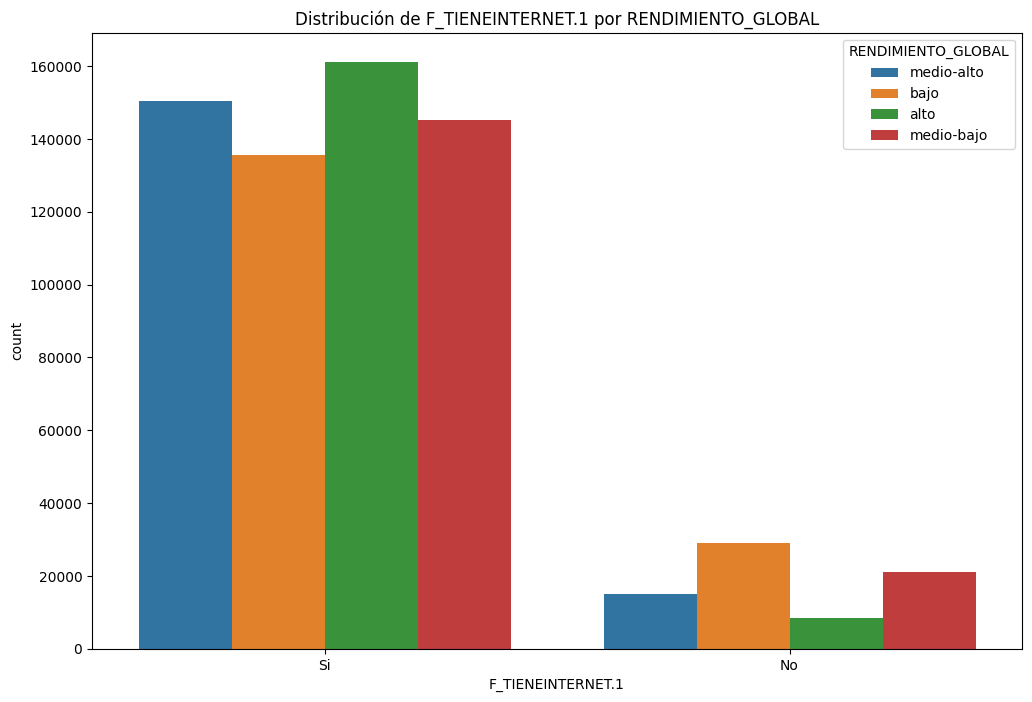

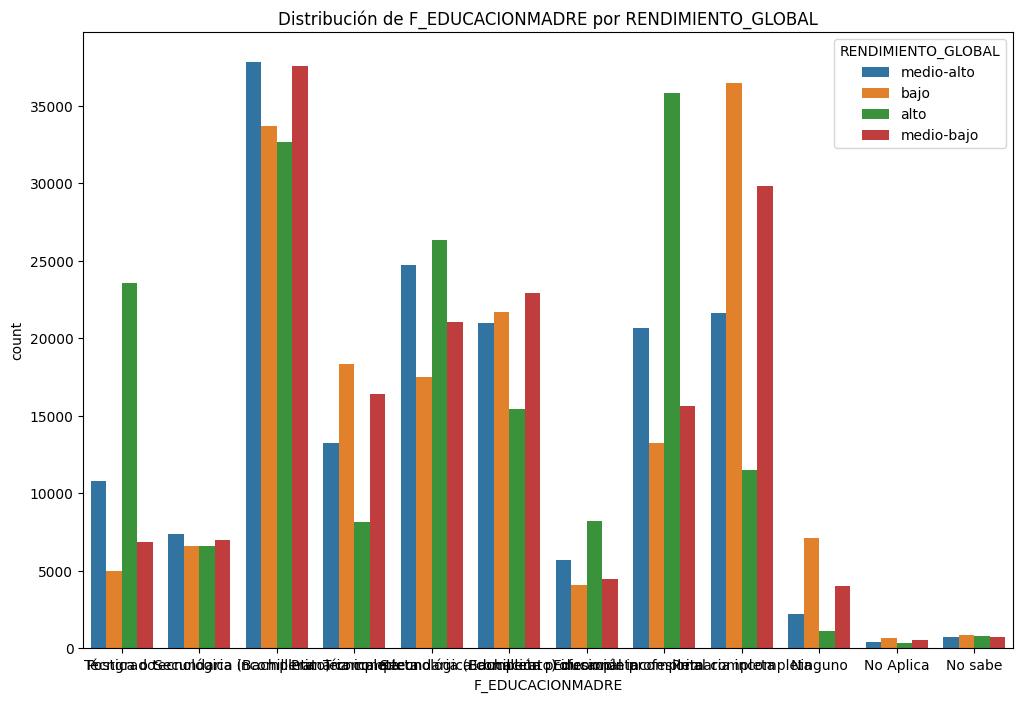

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


for columna in ['E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA', 'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_EDUCACIONPADRE', 'F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PAGOMATRICULAPROPIO', 'F_TIENECOMPUTADOR', 'F_TIENEINTERNET.1', 'F_EDUCACIONMADRE']:
    plt.figure(figsize=(12, 8))
    sns.countplot(data=df, x=columna, hue='RENDIMIENTO_GLOBAL')
    plt.title(f'Distribución de {columna} por RENDIMIENTO_GLOBAL')
    plt.legend(title='RENDIMIENTO_GLOBAL')
    plt.show()

In [15]:
df= df.copy()

In [16]:
df = df.drop('E_PRIVADO_LIBERTAD', axis=1)
df = df.drop('F_TIENEINTERNET.1', axis=1)

In [17]:
#variables categoricas
ccols = [i for i in df.columns if not i in df._get_numeric_data()]
print (ccols)

['E_PRGM_ACADEMICO', 'E_PRGM_DEPARTAMENTO', 'E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA', 'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_EDUCACIONPADRE', 'F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PAGOMATRICULAPROPIO', 'F_TIENECOMPUTADOR', 'F_EDUCACIONMADRE', 'RENDIMIENTO_GLOBAL']


Normalizacion de Valores

Para la columna F_ESTRATOVIVIENDA RENDIMIENTO_GLOBAL y se van a categorizar

In [18]:
df['F_ESTRATOVIVIENDA'] = df['F_ESTRATOVIVIENDA'].replace(['Estrato 1','Estrato 2','Estrato 3','Estrato 4','Estrato 5','Estrato 6','Sin Estrato'],[1,2,3,4,5,6,0])

/tmp/ipython-input-2486280523.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['F_ESTRATOVIVIENDA'] = df['F_ESTRATOVIVIENDA'].replace(['Estrato 1','Estrato 2','Estrato 3','Estrato 4','Estrato 5','Estrato 6','Sin Estrato'],[1,2,3,4,5,6,0])


In [19]:
rendimiento_mapping = {'bajo': 0, 'medio-bajo': 1, 'medio-alto': 2, 'alto': 3}
df['RENDIMIENTO_GLOBAL'] = df['RENDIMIENTO_GLOBAL'].replace(['bajo','medio-bajo','medio-alto','alto'],[1,2,3,4])

/tmp/ipython-input-38342113.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['RENDIMIENTO_GLOBAL'] = df['RENDIMIENTO_GLOBAL'].replace(['bajo','medio-bajo','medio-alto','alto'],[1,2,3,4])


Columnas de Si y No
Para las columnas con valores de Si y No que son:

FAMI_TIENEINTERNET, FAMI_TIENELAVADORA, FAMI_TIENEAUTOMOVIL, ESTU_PAGOMATRICULAPROPIO, FAMI_TIENECOMPUTADOR

In [20]:
#diccionario = {'Si': 1, 'No': 0}

#df_copy = df_copy[["FAMI_TIENEINTERNET","FAMI_TIENELAVADORA","FAMI_TIENEAUTOMOVIL","ESTU_PAGOMATRICULAPROPIO","FAMI_TIENECOMPUTADOR"]].replace(diccionario)

df["F_TIENEINTERNET"] = df["F_TIENEINTERNET"].replace({'Si': 1, 'No': 0})
df["F_TIENELAVADORA"] = df["F_TIENELAVADORA"].replace({'Si': 1, 'No': 0})
df["F_TIENEAUTOMOVIL"] = df["F_TIENEAUTOMOVIL"].replace({'Si': 1, 'No': 0})
df["E_PAGOMATRICULAPROPIO"] = df["E_PAGOMATRICULAPROPIO"].replace({'Si': 1, 'No': 0})
df["F_TIENECOMPUTADOR"] = df["F_TIENECOMPUTADOR"].replace({'Si': 1, 'No': 0})

/tmp/ipython-input-928903298.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["F_TIENEINTERNET"] = df["F_TIENEINTERNET"].replace({'Si': 1, 'No': 0})
/tmp/ipython-input-928903298.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["F_TIENELAVADORA"] = df["F_TIENELAVADORA"].replace({'Si': 1, 'No': 0})
/tmp/ipython-input-928903298.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-

Para la columna ESTU_VALORMATRICULAUNIVERSIDAD se va a categorizar

In [21]:
df['E_VALORMATRICULAUNIVERSIDAD'].replace(['No pagó matrícula'],[0],inplace=True)
df['E_VALORMATRICULAUNIVERSIDAD'].replace(['Menos de 500 mil'],[1],inplace=True)
df['E_VALORMATRICULAUNIVERSIDAD'].replace(['Entre 500 mil y menos de 1 millón'],[2],inplace=True)
df['E_VALORMATRICULAUNIVERSIDAD'].replace(['Entre 1 millón y menos de 2.5 millones'],[3],inplace=True)
df['E_VALORMATRICULAUNIVERSIDAD'].replace(['Entre 2.5 millones y menos de 4 millones'],[4],inplace=True)
df['E_VALORMATRICULAUNIVERSIDAD'].replace(['Entre 4 millones y menos de 5.5 millones'],[5],inplace=True)
df['E_VALORMATRICULAUNIVERSIDAD'].replace(['Entre 5.5 millones y menos de 7 millones'],[6],inplace=True)
df['E_VALORMATRICULAUNIVERSIDAD'].replace(['Más de 7 millones'],[7],inplace=True)

/tmp/ipython-input-710280898.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['E_VALORMATRICULAUNIVERSIDAD'].replace(['No pagó matrícula'],[0],inplace=True)
/tmp/ipython-input-710280898.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['E_VALORMATRICULAUNIVERSIDAD'].replace(['Más de 7 mil

Para la columna E_HORASSEMANATRABAJA

In [22]:
df['E_HORASSEMANATRABAJA'].replace(['0','Menos de 10 horas','Entre 11 y 20 horas','Entre 21 y 30 horas','Más de 30 horas'],[0,1,2,3,4],inplace=True)

/tmp/ipython-input-1517659701.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['E_HORASSEMANATRABAJA'].replace(['0','Menos de 10 horas','Entre 11 y 20 horas','Entre 21 y 30 horas','Más de 30 horas'],[0,1,2,3,4],inplace=True)
/tmp/ipython-input-1517659701.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcastin

ANÁLIS DE LA COLUMNA ESTU_PRGM_ACADEMICO

In [23]:
# Reemplazar la parte "PROFESIONAL EN" con una cadena vacía
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].str.replace('PROFESIONAL EN ', '')

Para la columna ESTU_PRGM_ACADEMICO se decide hacer agrupación por los programas que tengan alguna relación

Ejemplo:

Para todas las INGENIERIAS se decide reemplazar por la palabra INGENIERIA

Para todas las LICENCIATURAS se decide reemplazar por la palabra LICENCIATURA

In [24]:
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'INGENIERIA' if x.startswith('INGE') else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'LICENCIATURA' if x.startswith('LIC') or x.startswith('Lic') else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'ADMINISTRACION' if x.startswith('ADM')   else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'CONTADURIA' if x.startswith('CONT')   else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'COMUNICACION' if x.startswith('COMU')   else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'DEPORTE' if 'DEPORT'  in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'PSICOLOGIA' if 'PSIC' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'TRABAJO SOCIAL' if 'TRABAJO SOCIAL' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'DISEÑO' if 'DISE' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'TERAPIA' if 'TERAP' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'GASTRONOMIA' if 'GASTRON' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'VETERINARIA Y ZOOTECNIA' if 'ZOOTECNIA' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'NUTRICION' if 'NUTRIC' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'MARKETING' if ( 'MARKETING' in x or 'PUBLICIDAD' in x or 'MERCAD' in x) else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'MATEMATICAS Y ESTADISTICA' if ('MATE' in x or 'ESTA' in x) else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'ARTES' if 'ARTE' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'LITERATURA' if 'LITER' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'MUSICA' if ('MUS' in x or 'MÚS' in x) else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'ECONOMIA Y NEGOCIOS' if ('ECONO' in x or 'NEG' in x or 'COME' in x or 'FIN' in x) else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'CIENCIAS DE LA TIERRA' if 'GEO' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'CIENCIAS AUDIOVISUALES' if ('CINE' in x or 'RADIO' in x or 'TELEV' in x or 'AUDIOV' in x or 'FOTOG' in x) else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'DERECHO' if 'DERECHO' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'CIENCIAS POLITICAS' if ( 'POLIT' in x or 'POLÍT' in x) else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'INGENIERIA' if 'INGE' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'QUIMICA' if ('QUIM' in x or 'QUÍM' in x or 'QU¿M' in x) else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'CONSTRUCCION' if 'CONST' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'TURISMO' if 'TURIS' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'BIBLIOTECOLOGIA' if 'BIBLIO' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'FILOSOFIA' if 'FILOS' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'FILOLOGIA' if 'FILOL' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'ODONTOLOGIA' if 'ODONTOLOG' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'BIOLOGIA Y MICROBIOLOGIA' if 'BIOL' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'ECOLOGIA' if x.startswith('ECOL')   else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'BACTERIOLOGIA' if 'BACT' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].replace('ACUICULTURA', 'ACUICUlTURA')
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'CIENCIAS CULTURALES' if 'CULT' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'INSTRUMENTACION QUIRURGICA' if 'INSTRUMENTACION' in x else x)
df['E_PRGM_ACADEMICO'] = df['E_PRGM_ACADEMICO'].apply(lambda x: 'CIENCIAS MARITIMAS Y AERONAUTICAS' if ('MILIT' in x or 'NAVALES' in x or 'NAU' in x) else x)

In [25]:
# Calcula el conteo de cada valor en la columna 'ESTU_PRGM_ACADEMICO'
conteo_valores = df['E_PRGM_ACADEMICO'].value_counts()

# Obtén los valores que tienen menos de N registros
valores_menos_de_20 = conteo_valores[conteo_valores <= 20]
valores_menos_de_20

# Reemplaza los valores que tienen menos de N registros con 'OTRO PROGRAMA'
for valor in valores_menos_de_20.index:
    df.loc[df['E_PRGM_ACADEMICO'] == valor, 'E_PRGM_ACADEMICO'] = 'OTRO PROGRAMA'

Columnas ONE-HOT

In [26]:
df_encoded = pd.get_dummies(df, columns= ["E_PRGM_ACADEMICO","E_PRGM_DEPARTAMENTO","F_EDUCACIONPADRE","F_EDUCACIONMADRE"])

In [27]:
import numpy as np
# Select only numeric columns before checking for non-finite values
numeric_cols = df_encoded.select_dtypes(include=np.number).columns
non_finite_cols = df_encoded[numeric_cols].columns[~np.isfinite(df_encoded[numeric_cols]).all()]
print("Columns with non-finite values:", non_finite_cols)

# Drop columns with non-finite values
df_encoded = df_encoded.drop(columns=non_finite_cols.tolist())

# Exclude 'E_HORASSEMANATRABAJA' column from integer conversion
cols_to_convert = df_encoded.columns.difference(['E_HORASSEMANATRABAJA'])

df_encoded[cols_to_convert] = df_encoded[cols_to_convert].astype(int)
display(df_encoded)

Columns with non-finite values: Index(['E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA',
       'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_TIENELAVADORA',
       'F_TIENEAUTOMOVIL', 'E_PAGOMATRICULAPROPIO', 'F_TIENECOMPUTADOR'],
      dtype='object')


,ID,PERIODO_ACADEMICO,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4,E_PRGM_ACADEMICO_ACUICUlTURA,E_PRGM_ACADEMICO_ADMINISTRACION,E_PRGM_ACADEMICO_AGROINDUSTRIA,...,F_EDUCACIONMADRE_Ninguno,F_EDUCACIONMADRE_No Aplica,F_EDUCACIONMADRE_No sabe,F_EDUCACIONMADRE_Postgrado,F_EDUCACIONMADRE_Primaria completa,F_EDUCACIONMADRE_Primaria incompleta,F_EDUCACIONMADRE_Secundaria (Bachillerato) completa,F_EDUCACIONMADRE_Secundaria (Bachillerato) incompleta,F_EDUCACIONMADRE_Técnica o tecnológica completa,F_EDUCACIONMADRE_Técnica o tecnológica incompleta
0,904256,20212,3,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,645256,20212,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,308367,20203,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,470353,20195,4,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,989032,20212,2,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692495,25096,20195,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
692496,754213,20212,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
692497,504185,20183,2,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
692498,986620,20195,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [28]:
import pandas as pd

# Supongamos que 'df' es tu DataFrame preprocesado
df.to_csv('dataset_preprocesado.csv', index=False)

In [29]:
from google.colab import files
files.download('dataset_preprocesado.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>